# Electronic Union — System Demo

End-to-end walkthrough of the Electronic Union power system model:

1. **Network overview** — five fictional countries, their generators, and extendable battery sites
2. **Synthetic time series** — wind, solar, and load profiles across four representative weeks
3. **Battery mechanics** — run a full investment optimisation and inspect battery dispatch
4. **Tieline scenarios** — how interconnection changes where batteries are built

> **Prerequisites** — run `python scripts/precompute.py` from the repo root to generate
> `data/scenarios.parquet` before executing Section 4.

In [1]:
import sys
from pathlib import Path

# Make sure the repo root is on the path when running from notebooks/
repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## 1  Network Overview

In [2]:
from electronic_union import build_network, make_snapshots, attach_timeseries
from electronic_union.network import GENERATORS, BATTERY_SITES
from electronic_union.tielines import POTENTIAL_TIELINES

snapshots = make_snapshots()
n = build_network(snapshots=snapshots)
attach_timeseries(n, seed=42)

print(f"Snapshots : {len(n.snapshots):>6}  ({len(n.snapshots)//168} seasons × 168 h)")
print(f"Buses     : {len(n.buses):>6}")
print(f"Generators: {len(n.generators):>6}")
print(f"Loads     : {len(n.loads):>6}")
print(f"Batteries : {len(n.storage_units):>6}  (all extendable)")
print(f"Tie lines : {len(POTENTIAL_TIELINES):>6}  (potential — none active by default)")

Snapshots :    672  (4 seasons × 168 h)
Buses     :      5
Generators:     14
Loads     :      5
Batteries :     12  (all extendable)
Tie lines :      6  (potential — none active by default)


In [3]:
# Generator capacity by country and carrier
display(
    n.generators[["bus", "carrier", "p_nom", "marginal_cost"]]
    .sort_values(["bus", "carrier"])
    .style.format({"p_nom": "{:,.0f} MW", "marginal_cost": "€{:.0f}/MWh"})
    .set_caption("Existing generators (fixed capacity)")
)

,bus,carrier,p_nom,marginal_cost
name,,,,
Coalland Plant 1,Coalland,coal,700 MW,€44/MWh
Coalland Plant 2,Coalland,coal,700 MW,€48/MWh
Coalland Plant 3,Coalland,coal,400 MW,€55/MWh
Gaseous CCGT 1,Gaseous Isles,gas,500 MW,€65/MWh
Gaseous CCGT 2,Gaseous Isles,gas,400 MW,€68/MWh
Gaseous Peaker,Gaseous Isles,gas_ocgt,200 MW,€95/MWh
Nuclear Unit 1,Nuclear Republic,nuclear,"1,000 MW",€12/MWh
Nuclear Unit 2,Nuclear Republic,nuclear,800 MW,€14/MWh
Solar Peninsula Backup,Solar Peninsula,gas_ocgt,"1,500 MW",€260/MWh


In [4]:
# Battery sites
display(
    n.storage_units[["bus", "max_hours", "capital_cost"]]
    .style.format({"capital_cost": "€{:,.0f}/MW·yr", "max_hours": "{:.0f} h"})
    .set_caption("Extendable battery sites (optimiser sets p_nom)")
)

,bus,max_hours,capital_cost
name,,,
Windtopia Battery A,Windtopia,6 h,"€85,000/MW·yr"
Windtopia Battery B,Windtopia,6 h,"€112,000/MW·yr"
Gaseous Isles Battery A,Gaseous Isles,6 h,"€122,000/MW·yr"
Gaseous Isles Battery B,Gaseous Isles,6 h,"€145,000/MW·yr"
Gaseous Isles Battery C,Gaseous Isles,6 h,"€165,000/MW·yr"
Coalland Battery A,Coalland,6 h,"€72,000/MW·yr"
Coalland Battery B,Coalland,6 h,"€88,000/MW·yr"
Solar Peninsula Battery A,Solar Peninsula,6 h,"€68,000/MW·yr"
Solar Peninsula Battery B,Solar Peninsula,6 h,"€92,000/MW·yr"


In [5]:
# Potential tie lines
display(
    pd.DataFrame(POTENTIAL_TIELINES)[["name","bus0","bus1","p_nom","length_km","build_cost_meur"]]
    .style.format({"p_nom": "{:,} MW", "length_km": "{:,} km", "build_cost_meur": "€{:.1f}M"})
    .set_caption("Potential interconnectors")
)

,name,bus0,bus1,p_nom,length_km,build_cost_meur
0,Windtopia — Gaseous Isles,Windtopia,Gaseous Isles,500 MW,636 km,€954.6M
1,Windtopia — Coalland,Windtopia,Coalland,500 MW,636 km,€954.6M
2,Gaseous Isles — Nuclear Republic,Gaseous Isles,Nuclear Republic,500 MW,335 km,€503.1M
3,Coalland — Solar Peninsula,Coalland,Solar Peninsula,500 MW,335 km,€503.1M
4,Nuclear Republic — Solar Peninsula,Nuclear Republic,Solar Peninsula,500 MW,600 km,€900.0M
5,Gaseous Isles — Coalland,Gaseous Isles,Coalland,800 MW,900 km,€1350.0M


---
## 2  Synthetic Time Series

Four representative weeks (one per season), each 168 hours.  
Each snapshot is weighted ×13 so summed weights ≈ 8 736 h ≈ one year.

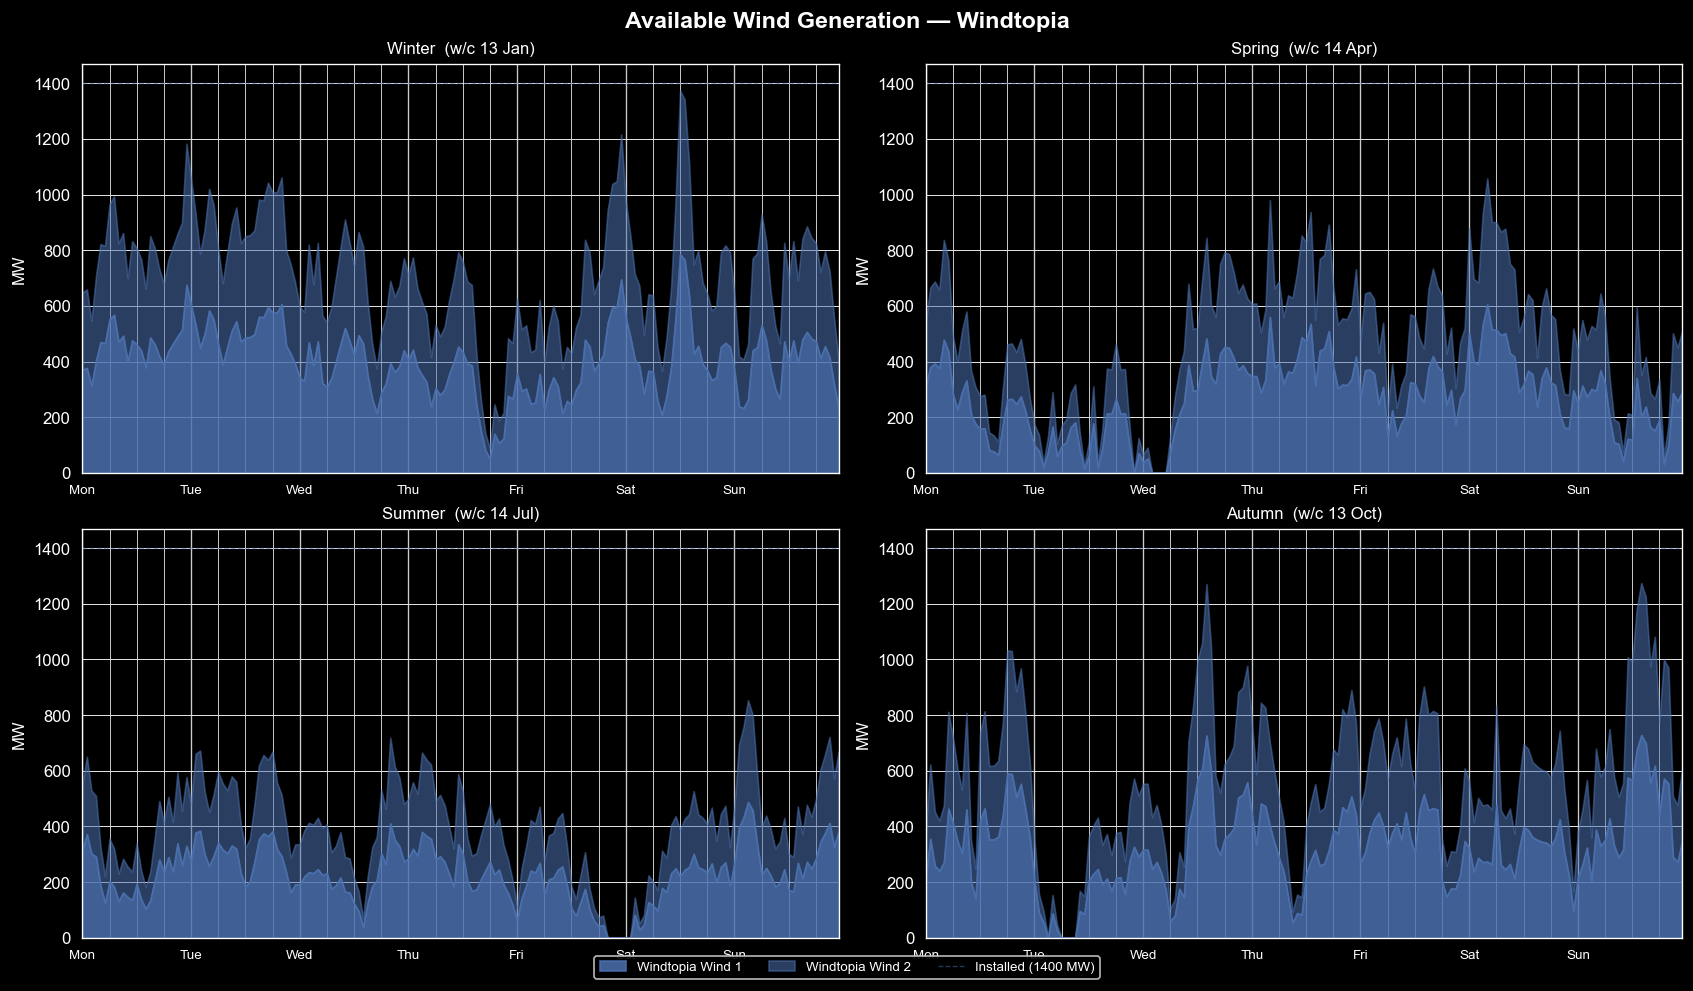

In [6]:
from electronic_union.plots import plot_wind, plot_solar, plot_loads, plot_wind_solar_overlay

fig = plot_wind(n)
plt.show()

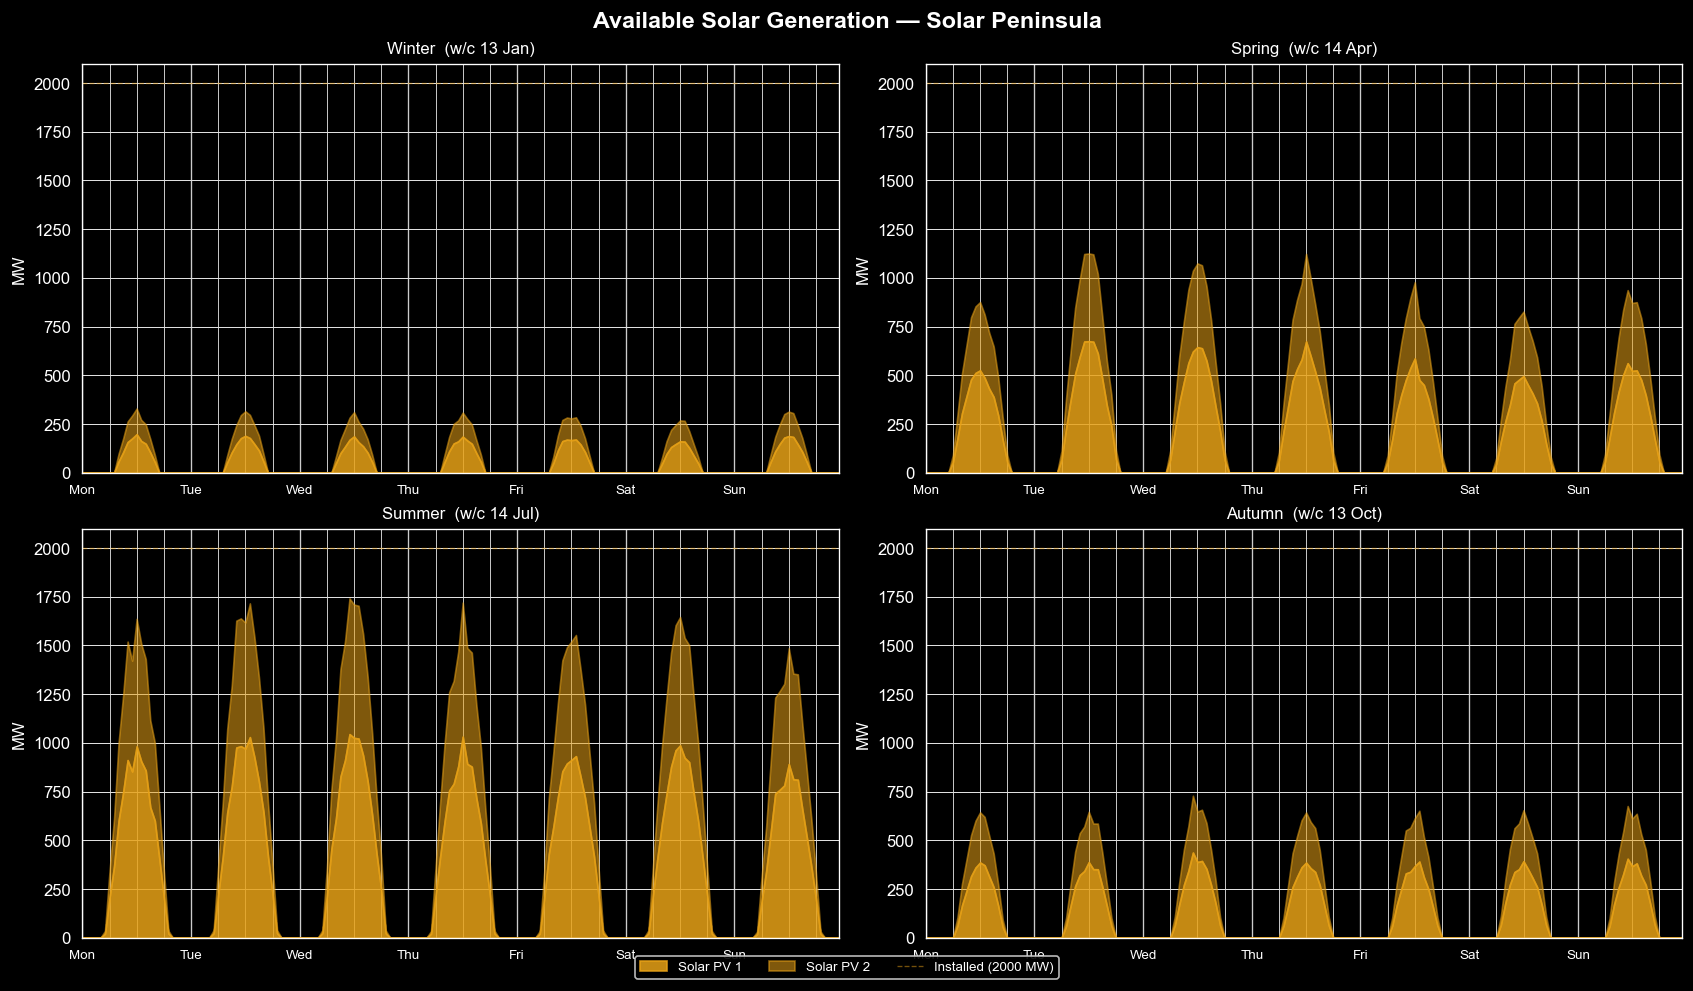

In [7]:
fig = plot_solar(n)
plt.show()

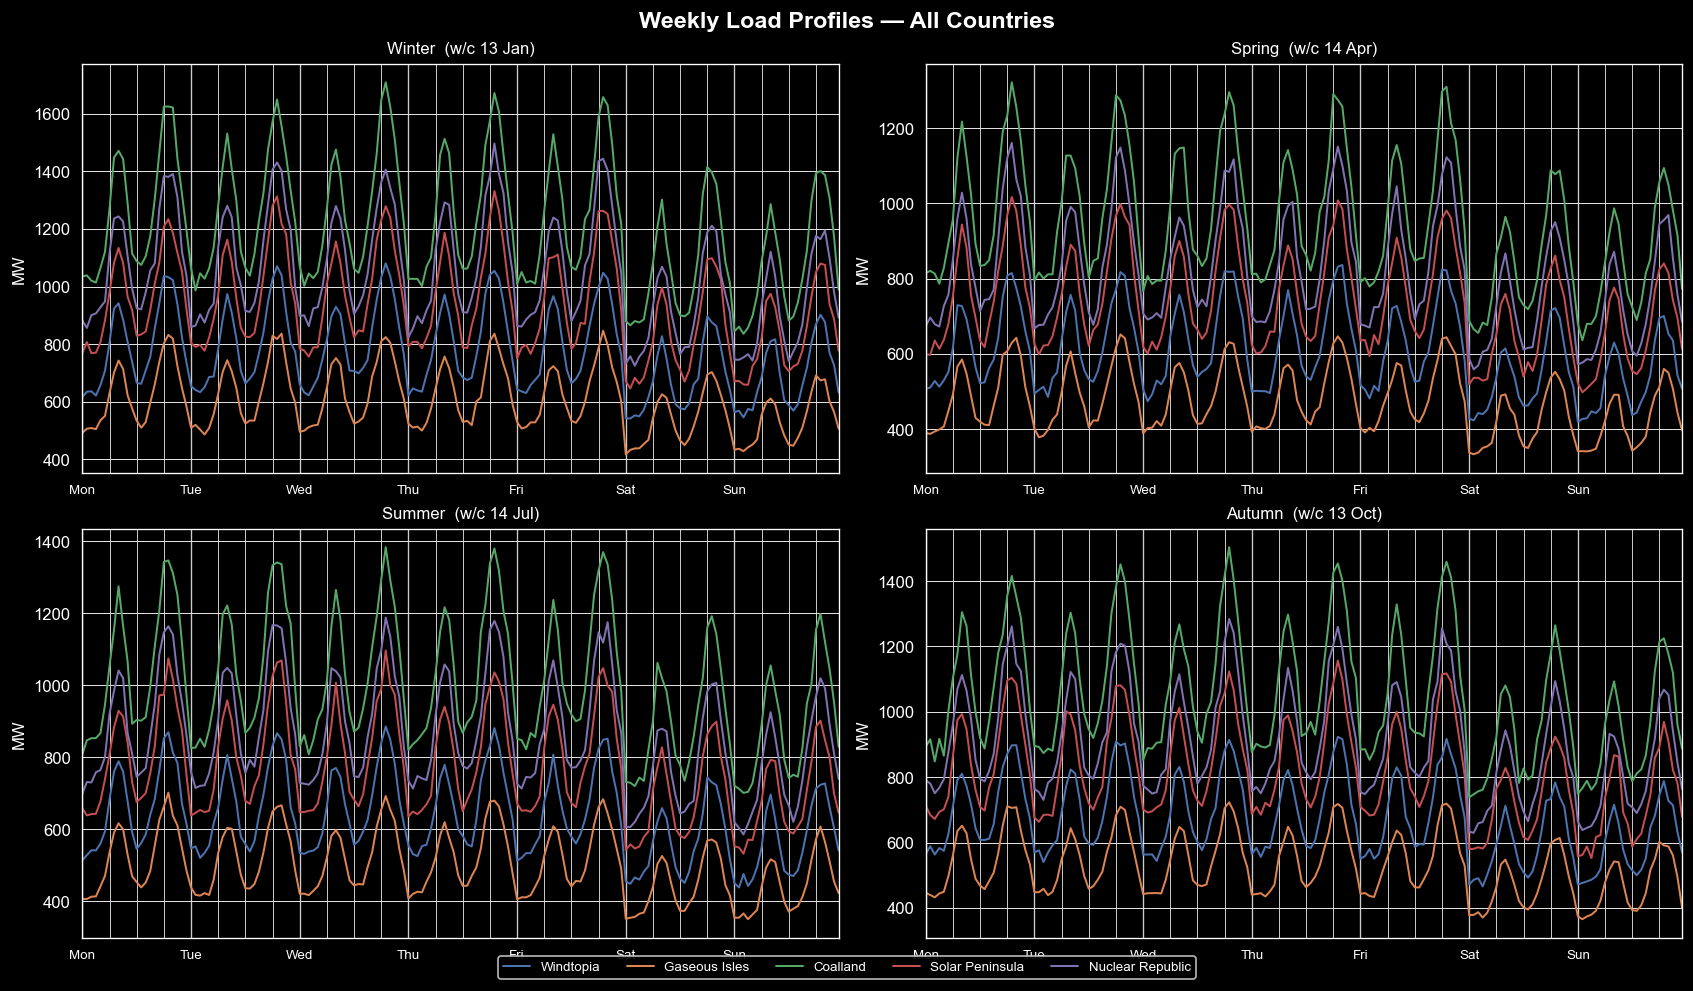

In [8]:
fig = plot_loads(n)
plt.show()

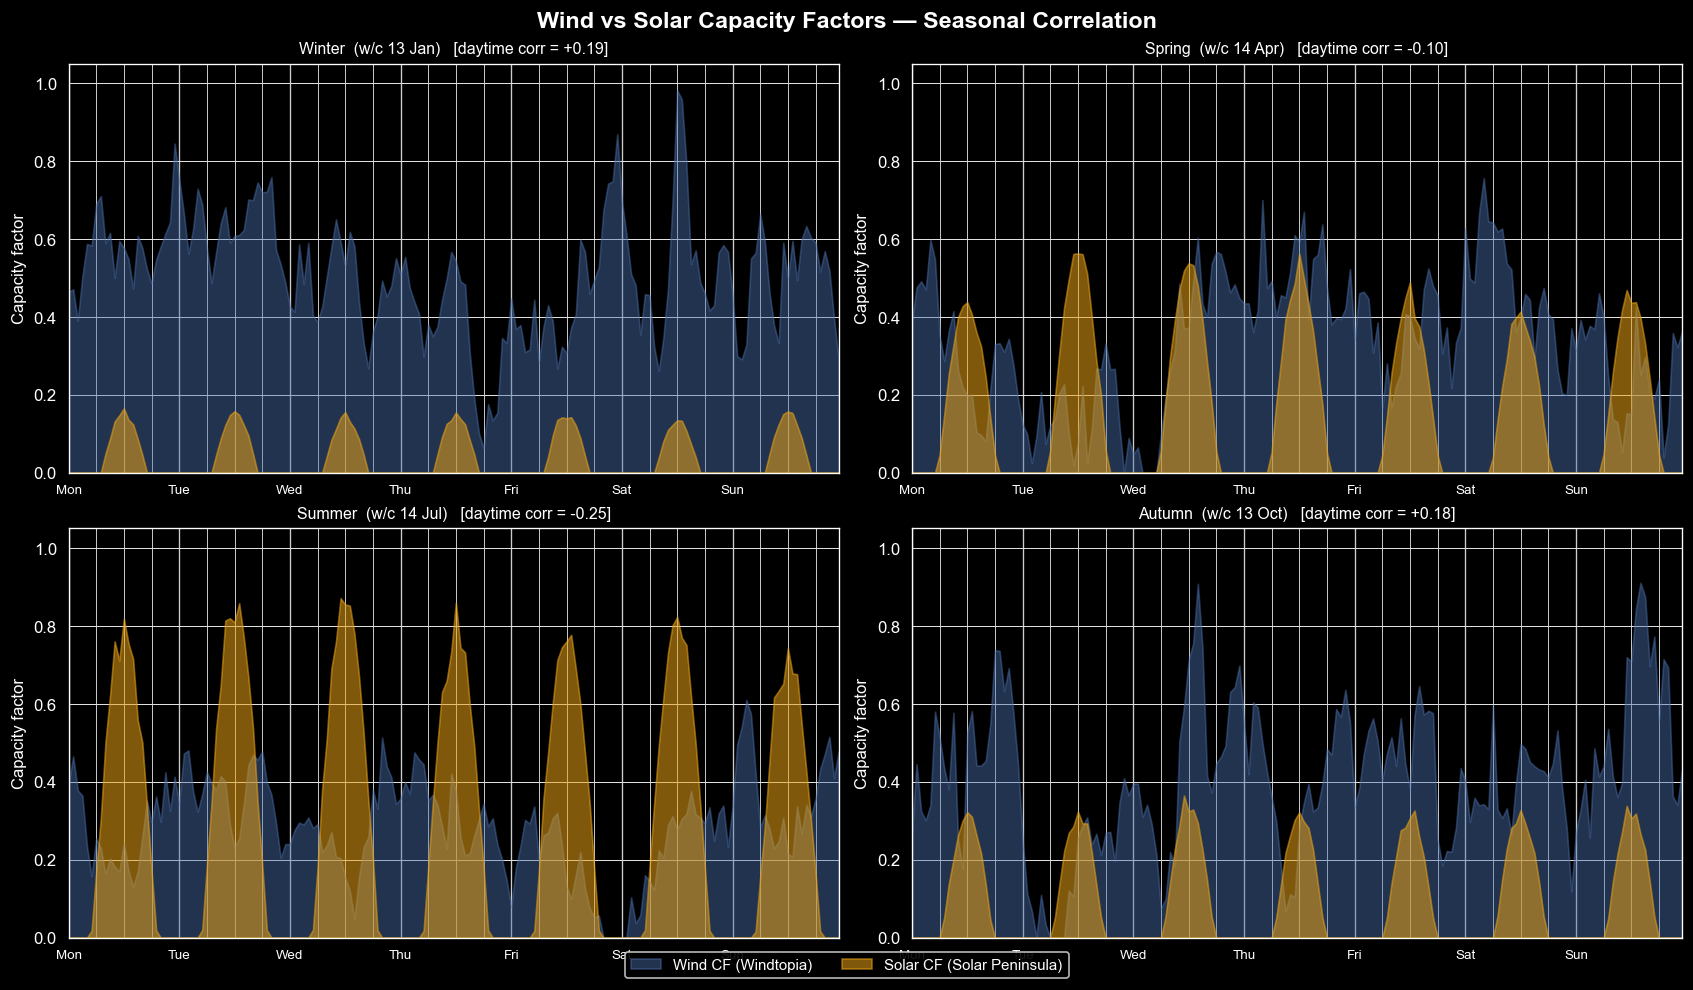

In [9]:
fig = plot_wind_solar_overlay(n)
plt.show()

---
## 3  Battery Mechanics

Optimise the **isolated** network (no tielines) to see where batteries are built and how they cycle.

In [ ]:
n.optimize(
    solver_name="highs",
    output_flag=False,
    include_objective_constant=False,
    progress=False,
)
print(f"Objective: €{n.objective:,.0f} / year")

In [11]:
# Optimised battery capacities
built = n.storage_units[["bus", "p_nom_opt", "max_hours"]].copy()
built["energy_capacity_mwh"] = built["p_nom_opt"] * built["max_hours"]
built = built[built["p_nom_opt"] > 0.1].sort_values("p_nom_opt", ascending=False)
display(
    built.style.format({"p_nom_opt": "{:.1f} MW", "max_hours": "{:.0f} h",
                        "energy_capacity_mwh": "{:.0f} MWh"})
    .set_caption("Built batteries")
)

,bus,p_nom_opt,max_hours,energy_capacity_mwh
name,,,,
Solar Peninsula Battery A,Solar Peninsula,788.1 MW,6 h,4729 MWh
Windtopia Battery A,Windtopia,406.3 MW,6 h,2438 MWh


In [12]:
# Country-level summary
countries = ["Windtopia", "Gaseous Isles", "Coalland", "Solar Peninsula", "Nuclear Republic"]
summary = []
for c in countries:
    mask = n.storage_units.bus == c
    total_mw = n.storage_units.loc[mask, "p_nom_opt"].sum()
    summary.append({"Country": c, "Total battery MW": total_mw})
display(
    pd.DataFrame(summary).set_index("Country")
    .style.format("{:.1f} MW")
)

,Total battery MW
Country,
Windtopia,406.3 MW
Gaseous Isles,0.0 MW
Coalland,0.0 MW
Solar Peninsula,788.1 MW
Nuclear Republic,0.0 MW


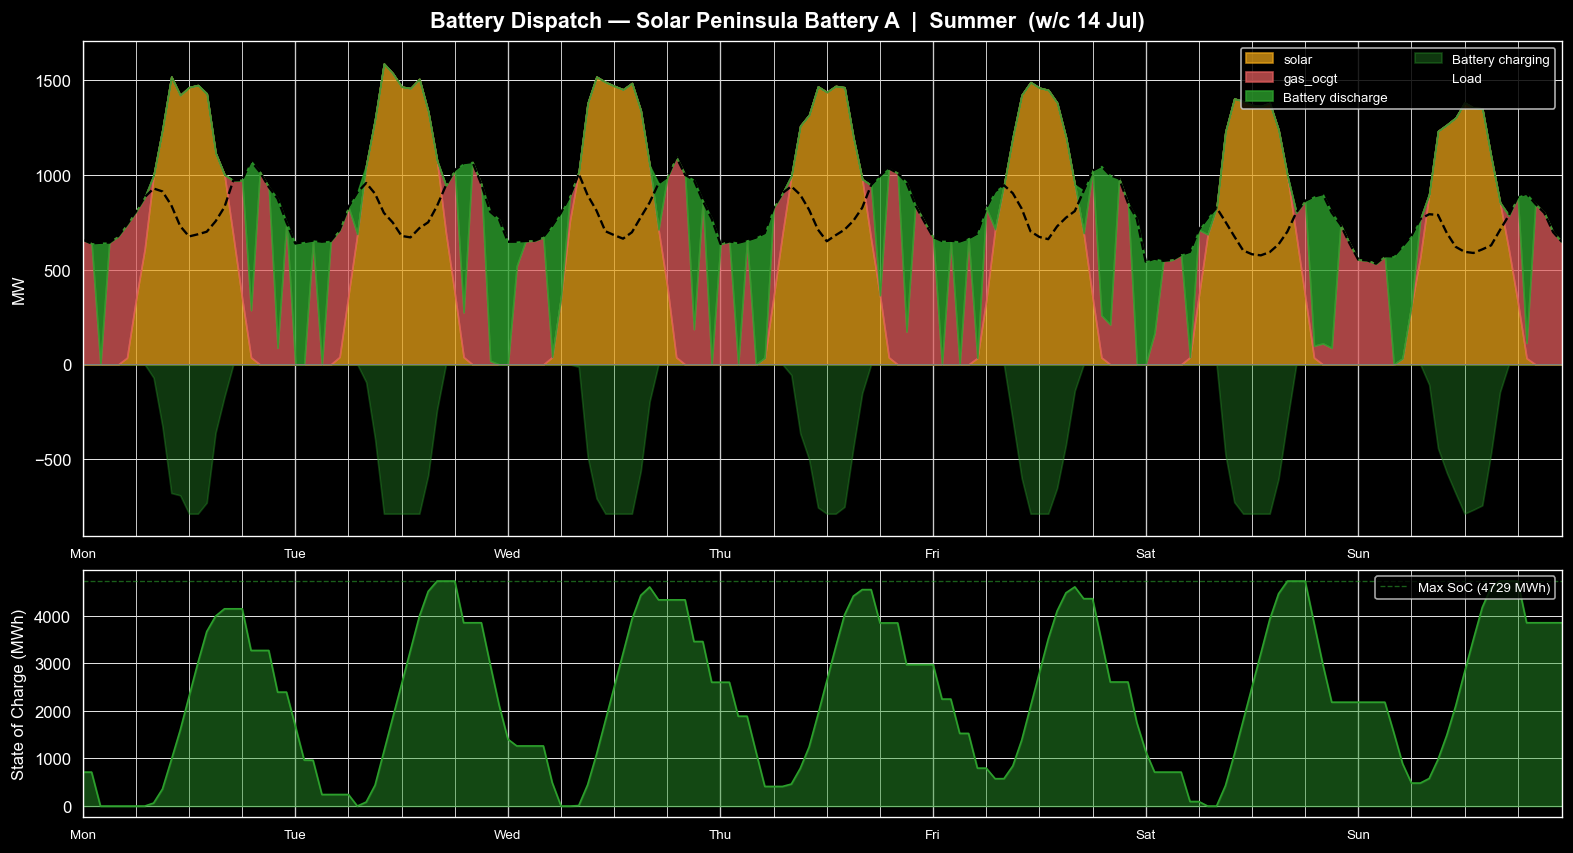

In [13]:
from electronic_union.plots import plot_battery_dispatch

# Show dispatch for the largest battery, summer week
fig = plot_battery_dispatch(n, season_idx=2)
plt.show()

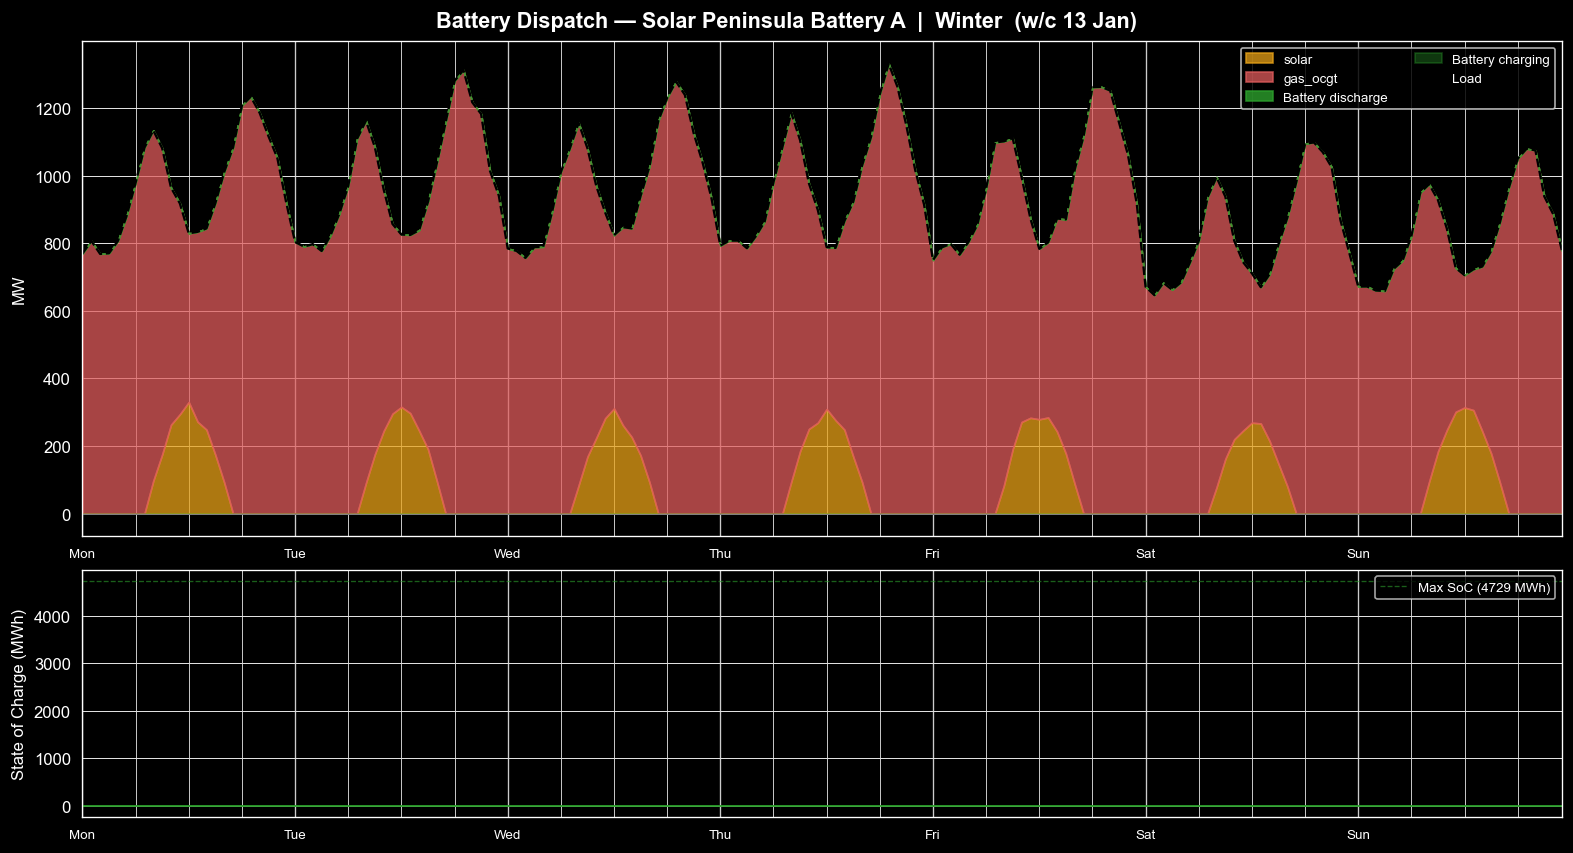

In [14]:
# Also show winter for comparison
largest = n.storage_units[n.storage_units.p_nom_opt > 0].p_nom_opt.idxmax()
fig = plot_battery_dispatch(n, storage_unit=largest, season_idx=0)
plt.show()

---
## 4  Tieline Scenarios

Load pre-computed results from `data/scenarios.parquet` (run `scripts/precompute.py` first).

We examine how adding interconnectors changes:
- **Total system cost**
- **Battery investment** by country
- **Dispatch mix** by carrier

In [15]:
parquet_path = repo_root / "data" / "scenarios.parquet"

if not parquet_path.exists():
    print("data/scenarios.parquet not found.")
    print("Run:  python scripts/precompute.py")
    df = None
else:
    df = pd.read_parquet(parquet_path)
    print(f"Loaded {len(df)} scenarios")
    df.head()

Loaded 64 scenarios


In [16]:
if df is not None:
    cost_by_n = df.groupby("n_tielines")["total_cost_eur"].agg(["min", "mean", "max"])
    cost_by_n.columns = ["Min cost", "Mean cost", "Max cost"]
    display(
        cost_by_n.style.format("€{:,.0f}")
        .set_caption("Annual system cost (€/yr) by number of active tielines")
    )

,Min cost,Mean cost,Max cost
n_tielines,,,
0,"€2,575,839,377","€2,575,839,377","€2,575,839,377"
1,"€1,731,497,787","€2,137,783,322","€2,514,795,177"
2,"€1,328,135,177","€1,763,849,742","€2,362,247,607"
3,"€1,084,869,860","€1,452,958,621","€2,101,410,555"
4,"€969,555,953","€1,204,649,873","€1,936,764,635"
5,"€947,324,131","€1,036,882,558","€1,201,150,706"
6,"€946,946,025","€946,946,025","€946,946,025"


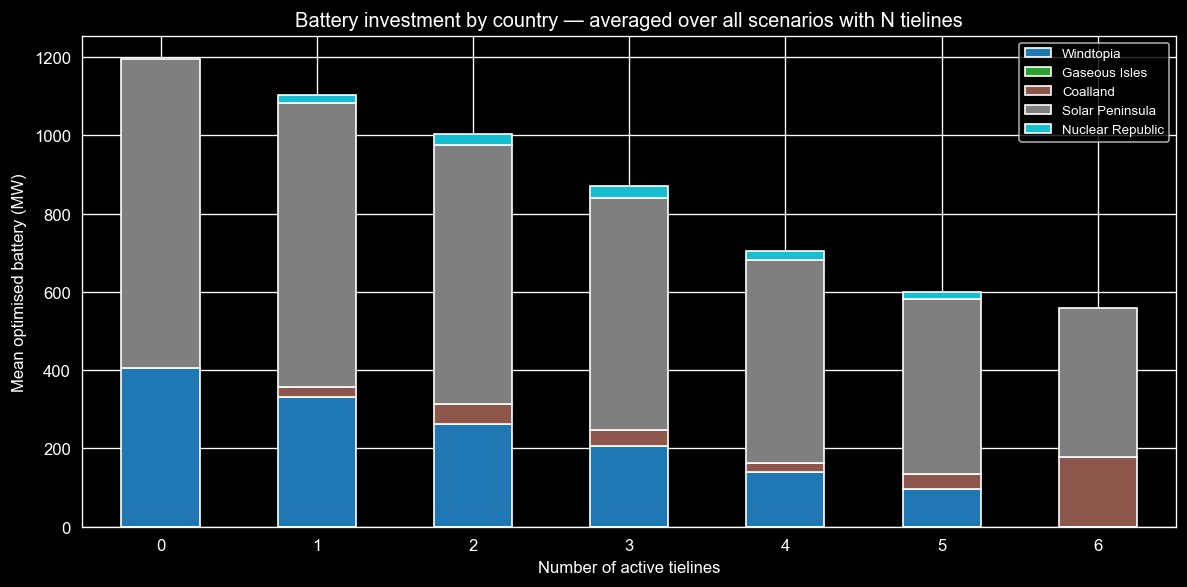

In [17]:
if df is not None:
    import matplotlib.pyplot as plt
    import numpy as np

    countries = ["Windtopia", "Gaseous Isles", "Coalland", "Solar Peninsula", "Nuclear Republic"]
    bat_cols = [f"bat_total_{c}" for c in countries]

    # Mean battery per country, grouped by n_tielines
    bat_mean = df.groupby("n_tielines")[bat_cols].mean()
    bat_mean.columns = countries

    fig, ax = plt.subplots(figsize=(10, 5))
    bat_mean.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
    ax.set_xlabel("Number of active tielines")
    ax.set_ylabel("Mean optimised battery (MW)")
    ax.set_title("Battery investment by country — averaged over all scenarios with N tielines")
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

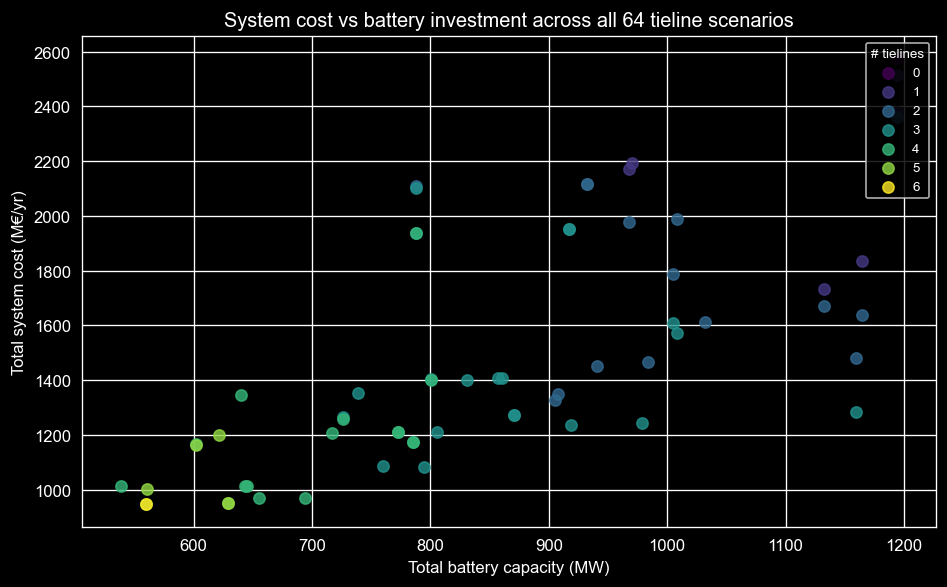

In [18]:
if df is not None:
    n_vals = sorted(df["n_tielines"].unique())   # [0, 1, 2, 3, 4, 5, 6]
    cmap = plt.get_cmap("viridis", len(n_vals))
    colour_map = {n_tl: cmap(i) for i, n_tl in enumerate(n_vals)}

    df["total_battery_mw"] = df[bat_cols].sum(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    for n_tl, group in df.groupby("n_tielines"):
        ax.scatter(
            group["total_battery_mw"],
            group["total_cost_eur"] / 1e6,
            color=colour_map[n_tl],
            alpha=0.8,
            s=45,
            label=str(n_tl),
        )

    ax.legend(title="# tielines", fontsize=8, title_fontsize=8,
              loc="upper right", framealpha=0.85)
    ax.set_xlabel("Total battery capacity (MW)")
    ax.set_ylabel("Total system cost (M€/yr)")
    ax.set_title("System cost vs battery investment across all 64 tieline scenarios")
    plt.tight_layout()
    plt.show()

In [19]:
if df is not None:
    display_cols = ["tielines", "n_tielines", "total_cost_eur", "total_battery_mw"]
    top10 = df.nsmallest(10, "total_cost_eur")[display_cols]
    display(
        top10.style.format({
            "total_cost_eur": "€{:,.0f}",
            "total_battery_mw": "{:.0f} MW",
        }).set_caption("Ten cheapest scenarios")
    )

,tielines,n_tielines,total_cost_eur,total_battery_mw
63,Windtopia — Gaseous Isles|Windtopia — Coalland|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland,6,"€946,946,025",560 MW
62,Windtopia — Gaseous Isles|Windtopia — Coalland|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula,5,"€947,324,131",560 MW
31,Windtopia — Coalland|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland,5,"€953,051,121",629 MW
47,Windtopia — Gaseous Isles|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland,5,"€953,051,121",629 MW
30,Windtopia — Coalland|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula,4,"€969,555,953",694 MW
46,Windtopia — Gaseous Isles|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula,4,"€970,972,384",655 MW
55,Windtopia — Gaseous Isles|Windtopia — Coalland|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland,5,"€1,003,521,621",561 MW
23,Windtopia — Coalland|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland,4,"€1,012,300,280",645 MW
39,Windtopia — Gaseous Isles|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland,4,"€1,013,454,948",643 MW
54,Windtopia — Gaseous Isles|Windtopia — Coalland|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula,4,"€1,013,854,879",539 MW


In [20]:
if df is not None:
    # Cost saving relative to isolated (no tielines)
    baseline = df[df["n_tielines"] == 0]["total_cost_eur"].iloc[0]
    df["cost_saving_meur"] = (baseline - df["total_cost_eur"]) / 1e6

    print(f"Baseline (no tielines): €{baseline:,.0f} / yr")
    best = df.nsmallest(1, "total_cost_eur").iloc[0]
    print(f"Best scenario        : {best['tielines']}")
    print(f"  Cost               : €{best['total_cost_eur']:,.0f} / yr")
    print(f"  Saving             : €{best['cost_saving_meur']:.1f} M / yr")

Baseline (no tielines): €2,575,839,377 / yr
Best scenario        : Windtopia — Gaseous Isles|Windtopia — Coalland|Gaseous Isles — Nuclear Republic|Coalland — Solar Peninsula|Nuclear Republic — Solar Peninsula|Gaseous Isles — Coalland
  Cost               : €946,946,025 / yr
  Saving             : €1628.9 M / yr


/Users/sarahinman/PycharmProjects/pypsa_exploration/notebooks
                             tielines  dispatch_mwh_wind  dispatch_mwh_battery
0                              (none)       4.614780e+06          7.655986e+05
1            Gaseous Isles — Coalland       4.614780e+06          7.655986e+05
2  Nuclear Republic — Solar Peninsula       4.614780e+06          1.141766e+06
